In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import time
import pandas as pd

# 1. Set seed for reproducibility
torch.manual_seed(0)
np.random.seed(0)

# Check device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}\n")

# --- A1. Tensor operations and shapes ---
print("--- A1. Tensor Operations ---")
t1 = torch.randn(3)       # (3,)
t2 = torch.randn(3, 4)    # (3, 4)
t3 = torch.randn(4, 3)    # (4, 3)

# Matrix multiply
matmul_res = t2 @ t3
print(f"Matrix multiply: {t2.shape} @ {t3.shape} -> {matmul_res.shape}")

# Element-wise multiply (broadcasting)
elem_res = t3 * t1
print(f"Element-wise (broadcasting): {t3.shape} * {t1.shape} -> {elem_res.shape}")

# Reshape, permute, flatten
print(f"View/Reshape: {t2.shape} -> {t2.view(2, 6).shape}")
print(f"Permute: {t2.shape} -> {t2.permute(1, 0).shape}")
print(f"Flatten: {t2.shape} -> {t2.flatten().shape}\n")

# --- A2. Autograd sanity check ---
print("--- A2. Autograd ---")
x = torch.tensor(2.0)
w = torch.tensor(3.0, requires_grad=True)
b = torch.tensor(1.0, requires_grad=True)

# PyTorch autograd
y = (w * x + b)**2
y.backward()
print(f"PyTorch gradients: dw={w.grad.item()}, db={b.grad.item()}")

# Manual gradients: y = (wx+b)^2 => dy/dw = 2(wx+b)x, dy/db = 2(wx+b)
dw_manual = 2 * (w.item() * x.item() + b.item()) * x.item()
db_manual = 2 * (w.item() * x.item() + b.item())
print(f"Manual gradients:  dw={dw_manual}, db={db_manual}")

Using device: cpu

--- A1. Tensor Operations ---
Matrix multiply: torch.Size([3, 4]) @ torch.Size([4, 3]) -> torch.Size([3, 3])
Element-wise (broadcasting): torch.Size([4, 3]) * torch.Size([3]) -> torch.Size([4, 3])
View/Reshape: torch.Size([3, 4]) -> torch.Size([2, 6])
Permute: torch.Size([3, 4]) -> torch.Size([4, 3])
Flatten: torch.Size([3, 4]) -> torch.Size([12])

--- A2. Autograd ---
PyTorch gradients: dw=28.0, db=14.0
Manual gradients:  dw=28.0, db=14.0


100%|██████████| 170M/170M [00:04<00:00, 34.5MB/s]


Batch shape: Images torch.Size([64, 3, 32, 32]), Labels torch.Size([64])


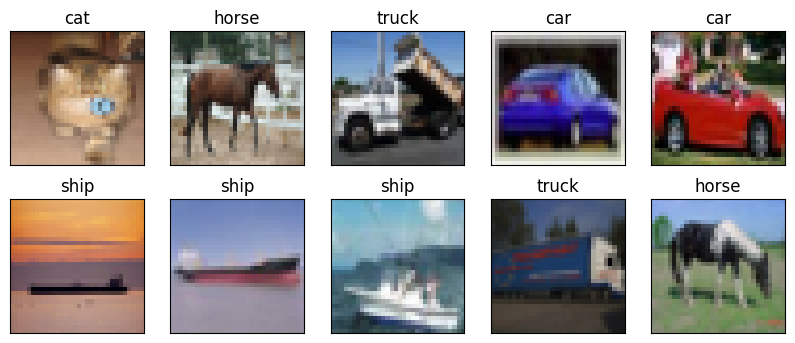

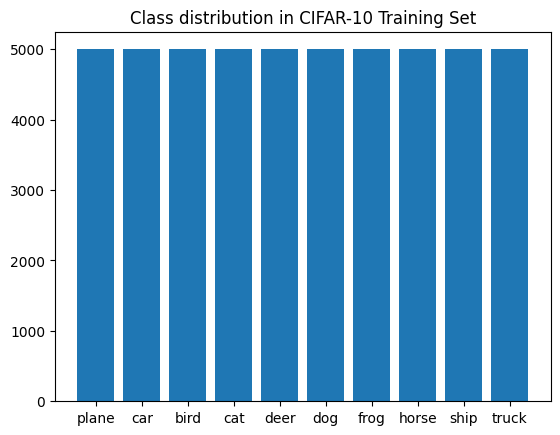

In [ ]:
# --- B3. Preprocessing ---
# Normalize using standard CIFAR-10 mean and std
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])

# --- B1. Load the dataset ---
batch_size = 64
trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size, shuffle=True)

testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size, shuffle=False)

classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

# --- B2. Explore and visualize ---
dataiter = iter(trainloader)
images, labels = next(dataiter)
print(f"Batch shape: Images {images.shape}, Labels {labels.shape}")

# Function to unnormalize and show an image
def imshow(img):
    img = img * torch.tensor([0.2023, 0.1994, 0.2010]).view(3, 1, 1) + \
          torch.tensor([0.4914, 0.4822, 0.4465]).view(3, 1, 1)
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))

# Show a 5x2 grid
fig = plt.figure(figsize=(10, 4))
for i in range(10):
    ax = fig.add_subplot(2, 5, i+1, xticks=[], yticks=[])
    imshow(images[i])
    ax.set_title(classes[labels[i]])
plt.show()

# Plot class counts
class_counts = np.zeros(10)
for _, labels_batch in trainloader:
    for label in labels_batch:
        class_counts[label] += 1

plt.bar(classes, class_counts)
plt.title("Class distribution in CIFAR-10 Training Set")
plt.show()

In [ ]:
# --- C1. Baseline MLP ---
class BaselineMLP(nn.Module):
    def __init__(self):
        super(BaselineMLP, self).__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(3072, 256)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(256, 128)
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(128, 10)
        # Note: No Softmax here because nn.CrossEntropyLoss expects raw logits

    def forward(self, x):
        x = self.flatten(x)
        x = self.relu1(self.fc1(x))
        x = self.relu2(self.fc2(x))
        logits = self.fc3(x)
        return logits

# --- Universal Training Function ---
def train_experiment(model, optimizer, criterion, epochs=15, title="Training Run"):
    train_losses, train_accs, val_accs = [], [], []
    best_val_acc = 0.0
    start_time = time.time()

    for epoch in range(epochs):
        # Training Phase
        model.train()
        running_loss, correct_train, total_train = 0.0, 0, 0

        for inputs, labels in trainloader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()

        epoch_train_loss = running_loss / total_train
        epoch_train_acc = 100.0 * correct_train / total_train
        train_losses.append(epoch_train_loss)
        train_accs.append(epoch_train_acc)

        # Validation Phase
        model.eval()
        correct_val, total_val = 0, 0
        with torch.no_grad():
            for inputs, labels in testloader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                _, predicted = torch.max(outputs, 1)
                total_val += labels.size(0)
                correct_val += (predicted == labels).sum().item()

        epoch_val_acc = 100.0 * correct_val / total_val
        val_accs.append(epoch_val_acc)

        if epoch_val_acc > best_val_acc:
            best_val_acc = epoch_val_acc

    train_time = time.time() - start_time

    # Plotting
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(title)
    ax1.plot(train_losses, label='Train Loss', color='blue')
    ax1.set_xlabel('Epoch'), ax1.set_ylabel('Loss'), ax1.legend()
    ax2.plot(train_accs, label='Train Acc', color='green')
    ax2.plot(val_accs, label='Val Acc', color='orange')
    ax2.set_xlabel('Epoch'), ax2.set_ylabel('Accuracy (%)'), ax2.legend()
    plt.show()

    return best_val_acc, val_accs[-1], train_time

# Print parameters for Baseline
temp_model = BaselineMLP()
print(f"Total parameters in Baseline: {sum(p.numel() for p in temp_model.parameters())}")

Total parameters in Baseline: 820874


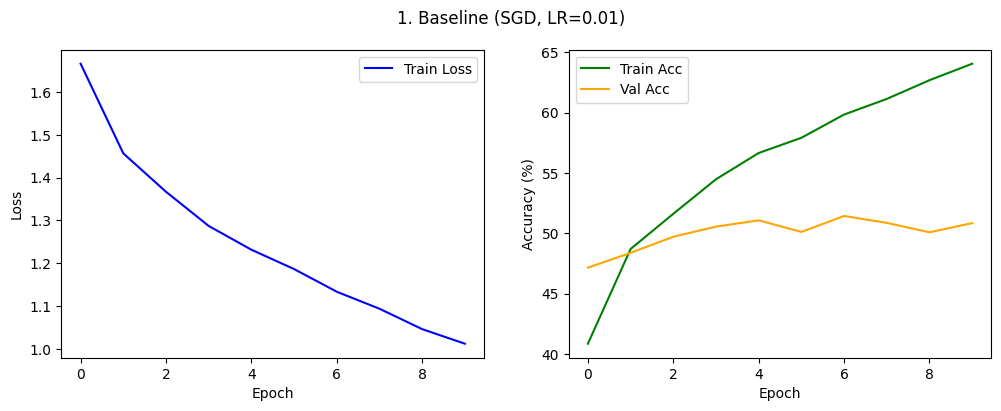

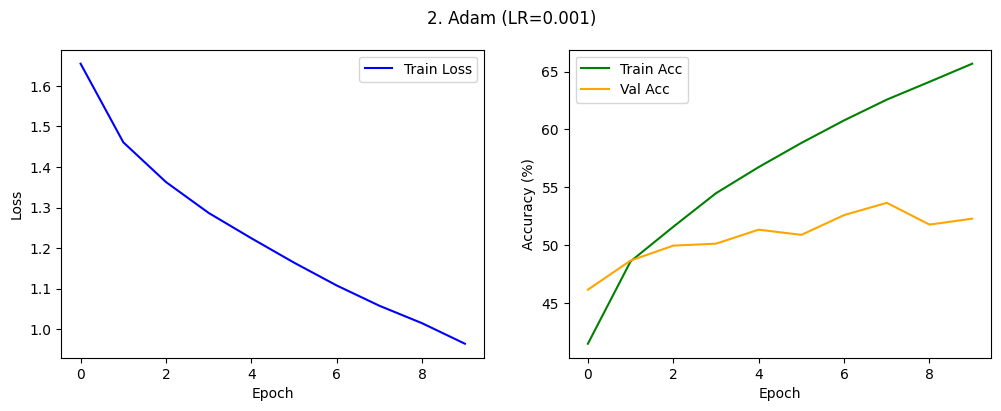

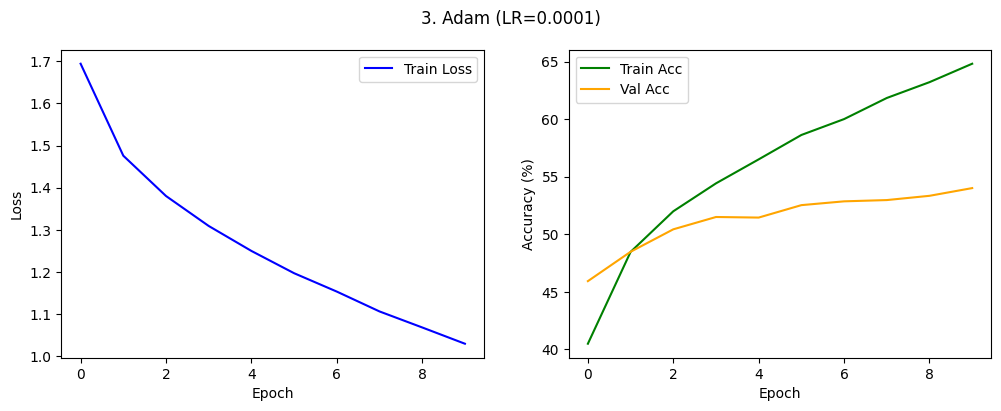

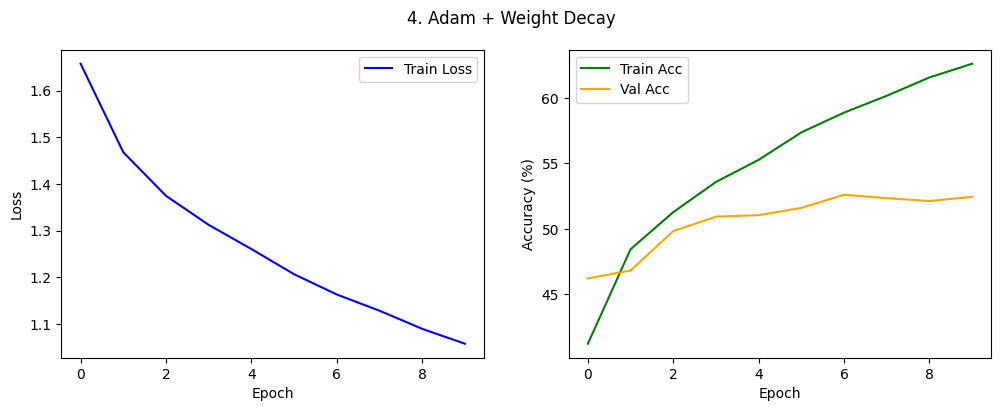

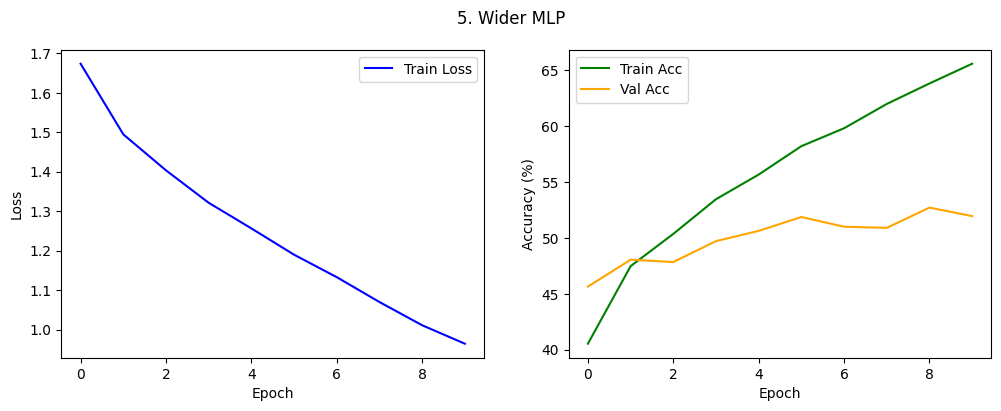

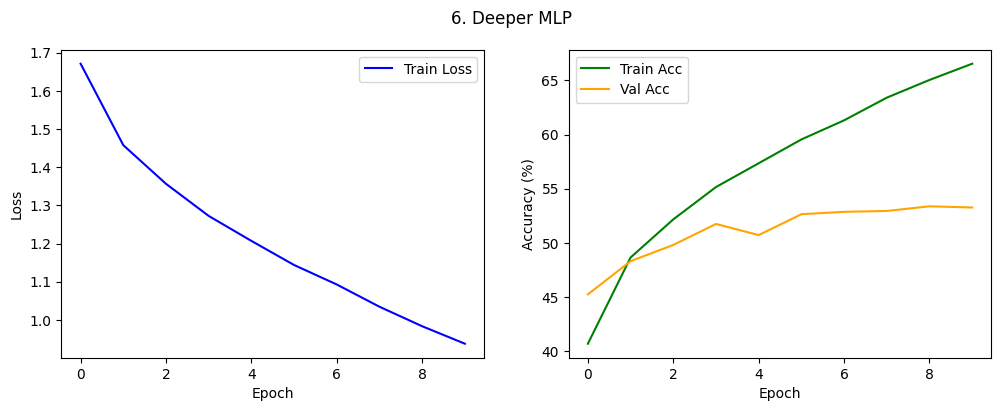

,Model,Opt,LR,Weight Decay,Best Val,Final Val,Time(s)
0,Baseline,SGD,0.0100,0.0000,51.43,50.84,242
1,Baseline,Adam,0.0010,0.0000,53.66,52.29,271
2,Baseline,Adam,0.0001,0.0000,54.01,54.01,267
3,Baseline,Adam,0.0010,0.0001,52.61,52.45,279
4,Wider,Adam,0.0010,0.0000,52.71,51.95,597
5,Deeper,Adam,0.0010,0.0000,53.37,53.26,275


In [ ]:
results = []
epochs_to_run = 10 # Set to 10-15 to keep runtime reasonable
criterion = nn.CrossEntropyLoss()

# 1. Baseline
model1 = BaselineMLP().to(device)
opt1 = optim.SGD(model1.parameters(), lr=0.01, momentum=0.9)
best, final, t_time = train_experiment(model1, opt1, criterion, epochs_to_run, "1. Baseline (SGD, LR=0.01)")
results.append({"Model": "Baseline", "Opt": "SGD", "LR": 0.01, "Weight Decay": 0, "Best Val": best, "Final Val": final, "Time(s)": round(t_time)})

# 2. Adam Optimizer
model2 = BaselineMLP().to(device)
opt2 = optim.Adam(model2.parameters(), lr=0.001)
best, final, t_time = train_experiment(model2, opt2, criterion, epochs_to_run, "2. Adam (LR=0.001)")
results.append({"Model": "Baseline", "Opt": "Adam", "LR": 0.001, "Weight Decay": 0, "Best Val": best, "Final Val": final, "Time(s)": round(t_time)})

# 3. Adam with smaller LR
model3 = BaselineMLP().to(device)
opt3 = optim.Adam(model3.parameters(), lr=0.0001)
best, final, t_time = train_experiment(model3, opt3, criterion, epochs_to_run, "3. Adam (LR=0.0001)")
results.append({"Model": "Baseline", "Opt": "Adam", "LR": 0.0001, "Weight Decay": 0, "Best Val": best, "Final Val": final, "Time(s)": round(t_time)})

# 4. Adam with Weight Decay (L2 Reg)
model4 = BaselineMLP().to(device)
opt4 = optim.Adam(model4.parameters(), lr=0.001, weight_decay=1e-4)
best, final, t_time = train_experiment(model4, opt4, criterion, epochs_to_run, "4. Adam + Weight Decay")
results.append({"Model": "Baseline", "Opt": "Adam", "LR": 0.001, "Weight Decay": 1e-4, "Best Val": best, "Final Val": final, "Time(s)": round(t_time)})

# --- Define Wider and Deeper Models ---
class WiderMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(3072, 1024), nn.ReLU(),
            nn.Linear(1024, 512), nn.ReLU(),
            nn.Linear(512, 10)
        )
    def forward(self, x): return self.net(x)

class DeeperMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(3072, 256), nn.ReLU(),
            nn.Linear(256, 128), nn.ReLU(),
            nn.Linear(128, 64), nn.ReLU(),
            nn.Linear(64, 10)
        )
    def forward(self, x): return self.net(x)

# 5. Wider MLP
model5 = WiderMLP().to(device)
opt5 = optim.Adam(model5.parameters(), lr=0.001)
best, final, t_time = train_experiment(model5, opt5, criterion, epochs_to_run, "5. Wider MLP")
results.append({"Model": "Wider", "Opt": "Adam", "LR": 0.001, "Weight Decay": 0, "Best Val": best, "Final Val": final, "Time(s)": round(t_time)})

# 6. Deeper MLP
model6 = DeeperMLP().to(device)
opt6 = optim.Adam(model6.parameters(), lr=0.001)
best, final, t_time = train_experiment(model6, opt6, criterion, epochs_to_run, "6. Deeper MLP")
results.append({"Model": "Deeper", "Opt": "Adam", "LR": 0.001, "Weight Decay": 0, "Best Val": best, "Final Val": final, "Time(s)": round(t_time)})

# --- Display Final Table ---
df_results = pd.DataFrame(results)
display(df_results)